<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Máquinas de Vetores de Suporte (SVM - Support Vector Machines)


As máquina de vetores de suporte são um tipo de algoritmo de aprendizado supervisionado utilizado para classificação ou regressão.

## Classificação

No processo de classificação, a ideia central é encontrar uma fronteira de decisão que separe as classes da melhor forma possível.

* Em duas dimensões, essa fronteira é uma reta.

* Em três dimensões, é um plano.

* Em dimensões maiores, chamamos essa fronteira de hiperplano.

Supondo um problema onde a classificação é binária, o hiperplano a ser encontrado pelo SVM é definido da seguinte forma:

$$
w^T x + b = 0
$$

Onde:

- $x$ representa o vetor de características;
- $w$ representa o vetor de pesos;
- $b$ representa o bias;
- $w^T x + b$ define a posição do ponto em relação ao hiperplano.

A decisão pode ser escrita como:

$$
\hat{y} = \text{sign}(w^T x + b)
$$

Se o resultado for positivo, o ponto pertence a uma classe. Se for negativo, pertence à outra.

A equação $$w^T x + b = 0$$ calcula de que lado do hiperplano o ponto está, ou seja, $+1$ ou $-1$.

Ou seja,

$\
\mathrm{sign}(x)=
\begin{cases}
+1, & \text{se } x > 0 \\
0, & \text{se } x = 0 \\
-1, & \text{se } x < 0
\end{cases}
\
$

## Exemplo matemático

Suponha:

\
\begin{aligned}
w &=
\begin{bmatrix}
2 \\
1
\end{bmatrix},
\quad
x =
\begin{bmatrix}
3 \\
4
\end{bmatrix},
\quad
b = -8
\end{aligned}

$w^T x + b = (2)(3) + (1)(4) - 8$


$w^T x + b = 6 + 4 - 8 = 2$

$\hat{y} = \operatorname{sign}(2)$



$\hat{y} = +1$


O SVM não procura apenas uma reta qualquer que separe as classes.

Ele procura a reta que produz a **maior margem possível** entre as classes.

A margem é a distância entre o hiperplano separador e os pontos mais próximos de cada classe.

Esses pontos mais próximos são chamados de **vetores de suporte**.

Quanto maior a margem, maior tende a ser a capacidade de generalização do modelo.

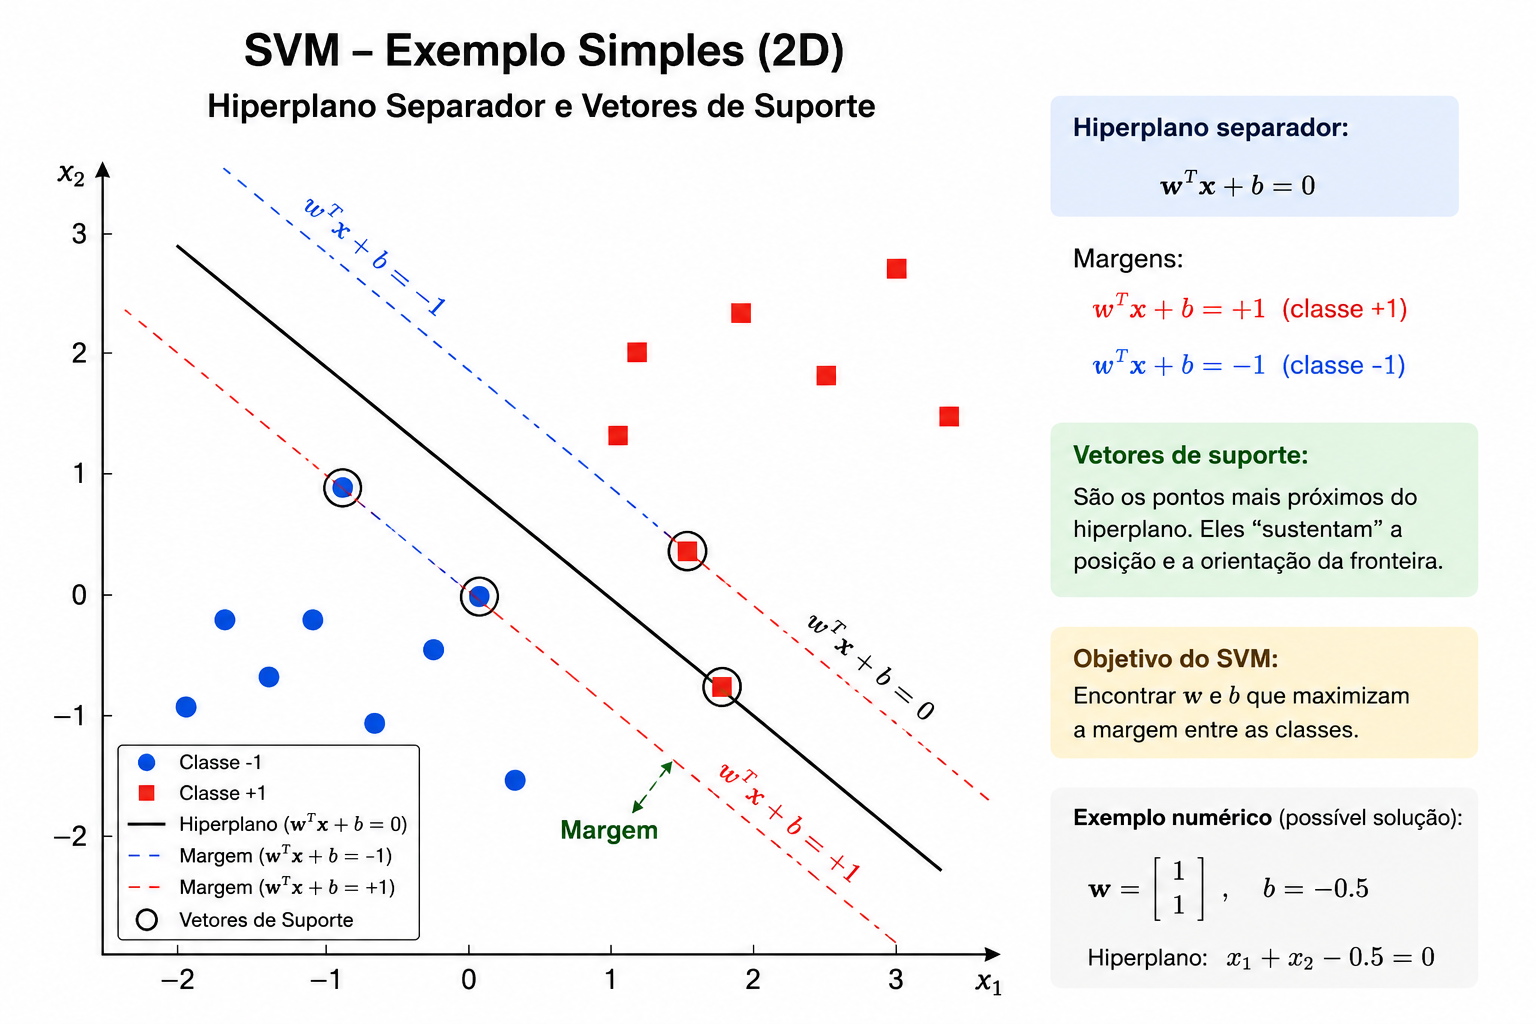

## Vetores de Suporte

Os **vetores de suporte** são os pontos de treinamento mais importantes para definir a fronteira de decisão.

São os pontos que ficam mais próximos do hiperplano separador.

Uma característica interessante do SVM é que nem todos os pontos de treinamento influenciam diretamente a fronteira. Em muitos casos, apenas os vetores de suporte são decisivos.


## Exemplo com dados sintéticos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

w = [0.46153846 0.30769231]
b = -3.3076923076923075
Vetores de suporte:
[[3. 3.]
 [6. 5.]]


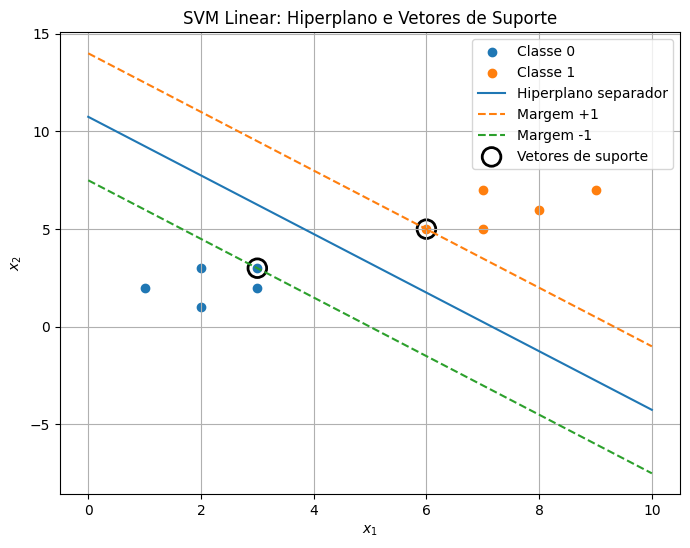

In [ ]:
# Dados simples em 2D
X = np.array([
    [1, 2], [2, 3], [3, 3], [2, 1], [3, 2],   # Classe 0
    [6, 5], [7, 7], [8, 6], [7, 5], [9, 7]    # Classe 1
])

y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Treinando o SVM linear
modelo = SVC(kernel='linear', C=1.0)
modelo.fit(X, y)

# Coeficientes do hiperplano
w = modelo.coef_[0]
b = modelo.intercept_[0]

print("w =", w)
print("b =", b)
print("Vetores de suporte:")
print(modelo.support_vectors_)

# Criando pontos para desenhar a reta
x_plot = np.linspace(0, 10, 100)

# Hiperplano: w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b)/w2
y_hiperplano = -(w[0] * x_plot + b) / w[1]

# Margens: w1*x1 + w2*x2 + b = +1 e -1
y_margem_pos = -(w[0] * x_plot + b - 1) / w[1]
y_margem_neg = -(w[0] * x_plot + b + 1) / w[1]

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Classe 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Classe 1")

# Hiperplano e margens
plt.plot(x_plot, y_hiperplano, label="Hiperplano separador")
plt.plot(x_plot, y_margem_pos, linestyle="--", label="Margem +1")
plt.plot(x_plot, y_margem_neg, linestyle="--", label="Margem -1")

# Vetores de suporte
plt.scatter(
    modelo.support_vectors_[:, 0],
    modelo.support_vectors_[:, 1],
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label="Vetores de suporte"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("SVM Linear: Hiperplano e Vetores de Suporte")
plt.legend()
plt.grid(True)
plt.show()

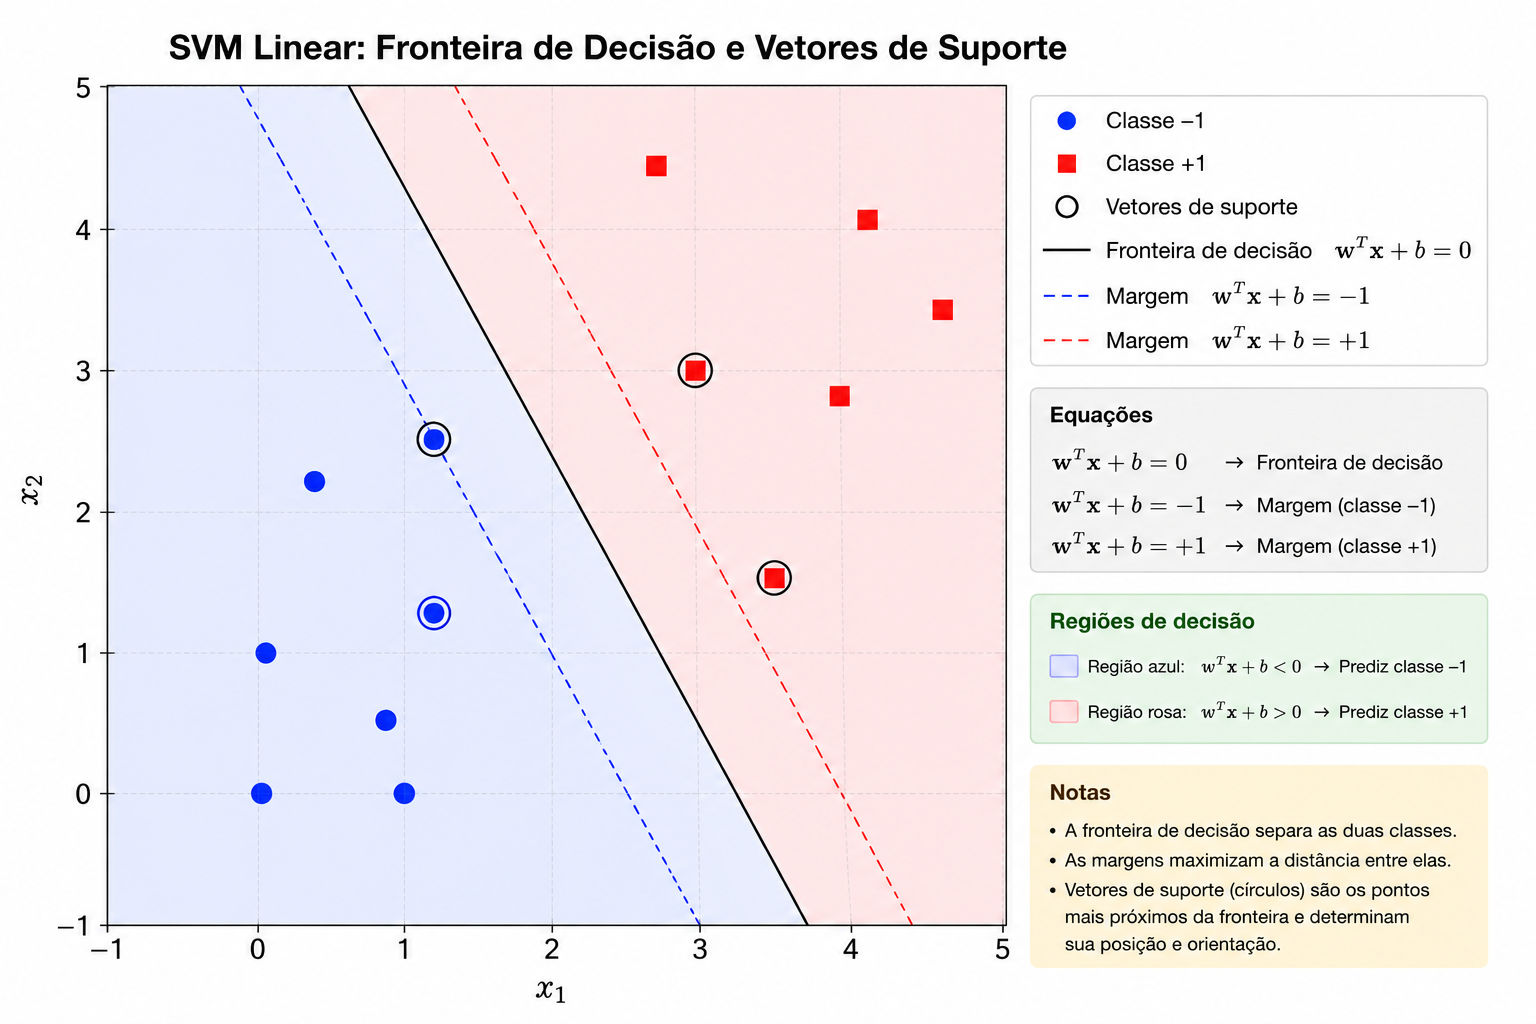

## O papel do Hyperparâmetro C

O parâmetro $c$ é responsável pelo equilíbrio entre maximizar a margem e reduzir erros de classificação no conjunto de treinamento.

## Valores pequenos de C

- permitem uma margem maior;
- toleram mais erros;
- podem gerar um modelo mais simples;
- podem causar underfitting.

## Valores grandes de C

- penalizam mais os erros;
- tentam classificar corretamente mais pontos de treino;
- podem gerar fronteiras mais ajustadas;
- podem causar overfitting.


## Truque de Kernel

Quando os dados não são linearmente separáveis mesmo assim é possível utilizar classificação SVM. Para tanto, basta mudar o kernel do algoritmo.

A ideia do kernel é permitir que o SVM encontre fronteiras não lineares sem precisar transformar explicitamente os dados para um espaço de dimensão maior.

Principais kernels:

* linear: fronteira linear;
* poly: fronteira polinomial;
* rbf: kernel radial, muito usado para fronteiras não lineares;
* sigmoid: relacionado a funções do tipo sigmoide.

O kernel mais comum em muitos problemas práticos é o rbf.

## Exemplo com mudança de Kernel

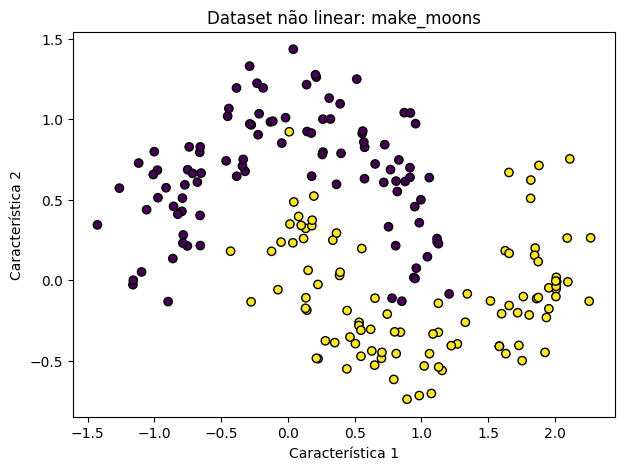

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=200, noise=0.18, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, edgecolor='k')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Dataset não linear: make_moons')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons
)

In [ ]:
from sklearn.svm import SVC

linear = SVC(kernel='linear', C=1.0)

rbf = SVC(kernel='rbf', C=1.0, gamma='scale')

In [ ]:
linear.fit(X_treino, y_treino)
rbf.fit(X_treino, y_treino)

SVC()

## Fronteira de Decisão (linear + RBF)

In [ ]:
def plot_decision_boundary(model, X, y, title='Fronteira de decisão'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title(title)
    plt.show()

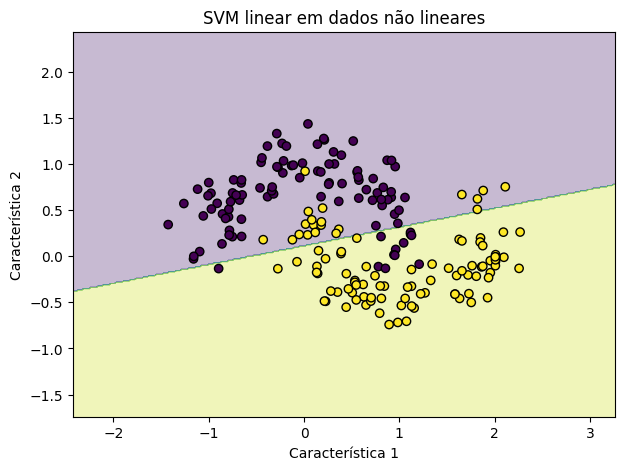

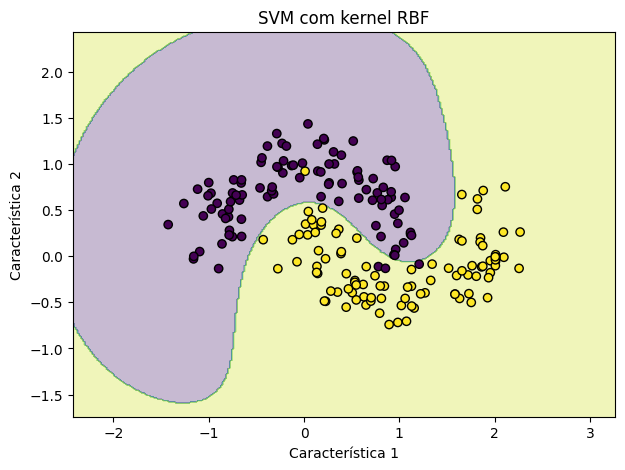

In [ ]:
plot_decision_boundary(linear, X_moons, y_moons, 'SVM linear em dados não lineares')
plot_decision_boundary(rbf, X_moons, y_moons, 'SVM com kernel RBF')

## O papel do Hyperparâmetro Gamma

O parâmetro `gamma` controla o alcance da influência de cada ponto de treinamento.

## Gamma pequeno

- influência mais ampla dos pontos;
- fronteira mais suave;
- pode causar underfitting.

## Gamma grande

- influência mais localizada;
- fronteira mais complexa;
- pode causar overfitting.

## Exemplo com variações do hyperparâmetro gamma

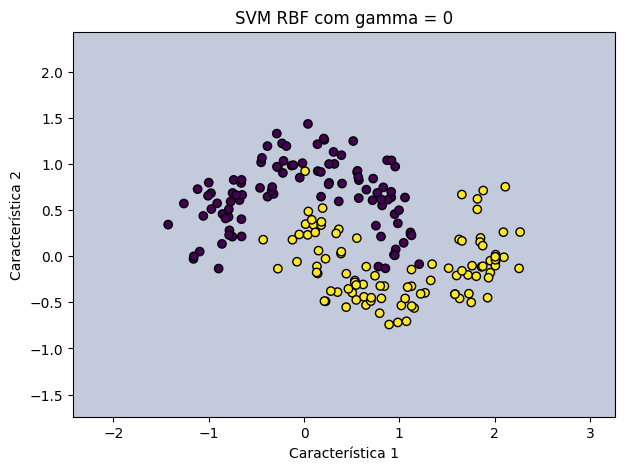

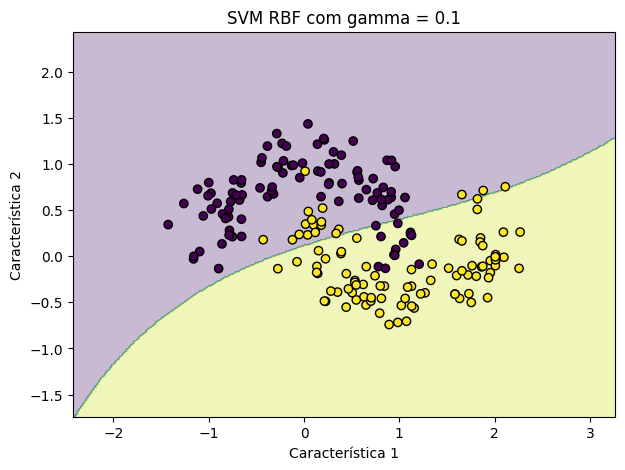

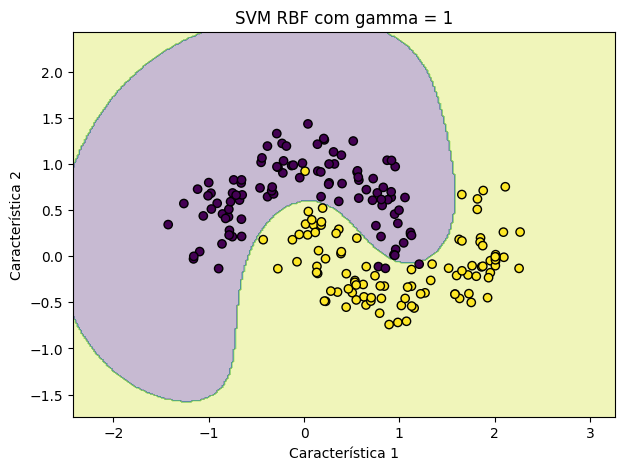

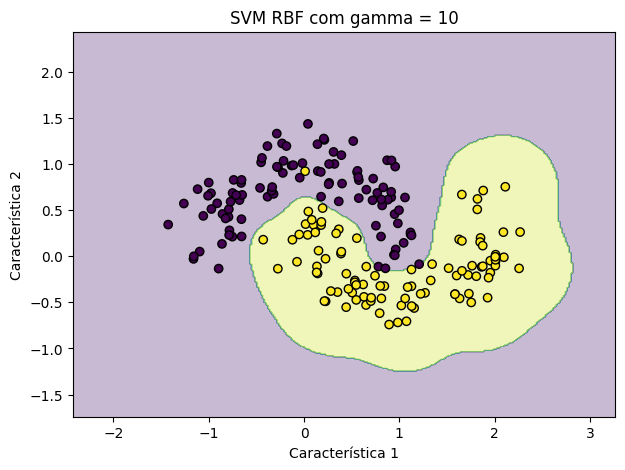

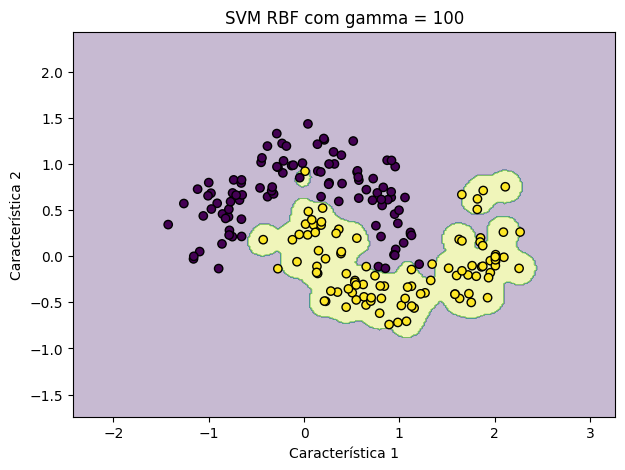

In [ ]:
gammas = [0, 0.1, 1, 10, 100]

for gamma in gammas:
    rbf = SVC(kernel='rbf', C=1.0, gamma=gamma)
    rbf.fit(X_treino, y_treino)
    plot_decision_boundary(rbf, X_moons, y_moons, f'SVM RBF com gamma = {gamma}')

## Exemplo de predição com SVM

In [ ]:
novo_ponto = np.array([[0.5, 0.2]])

classe_prevista = rbf.predict(novo_ponto)

print('Novo ponto:', novo_ponto)
print('Classe prevista:', classe_prevista[0])

Novo ponto: [[0.5 0.2]]
Classe prevista: 1


## Regressão

O SVM para regressão é chamada de **Support Vector Regression**, ou **SVR**.

Na regressão, em vez de separar classes, o SVM aproxima uma função para predizer valores contínuos.

A ideia central do SVR é construir uma função que tenha no máximo um erro tolerável $\epsilon$ para a maior parte dos pontos.

Esse intervalo é chamado de **tubo epsilon**.

No SVR, busca-se uma função do tipo:

$$
f(x) = w^T x + b
$$

O parâmetro $\epsilon$ define uma região ao redor da função em que os erros são tolerados.

Se um ponto está dentro do tubo de largura $\epsilon$, o erro pode não ser penalizado.

Se o ponto está fora do tubo, o erro passa a ser penalizado.

Em termos intuitivos:

- $\epsilon$ pequeno: modelo tenta ser mais preciso;
- $\epsilon$ grande: modelo tolera mais desvios;
- `C` alto: penaliza fortemente erros fora do tubo;
- `C` baixo: permite mais flexibilidade.

## Exemplo de regressão com o SVM (kernel linear)

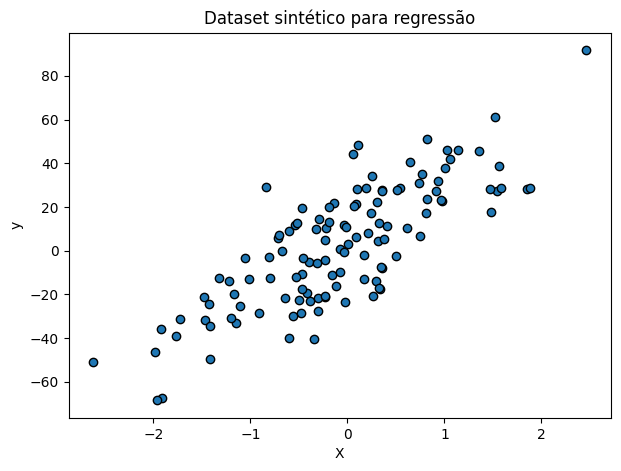

In [ ]:
from sklearn.datasets import make_regression
from sklearn.svm import SVR

X_reg, y_reg = make_regression(
    n_samples=120,
    n_features=1,
    noise=18,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_reg, y_reg, edgecolor='k')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dataset sintético para regressão')
plt.show()


In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

regressor = SVR(kernel='linear', C=10, epsilon=5)

regressor.fit(X_treino, y_treino)

SVR(C=10, epsilon=5, kernel='linear')

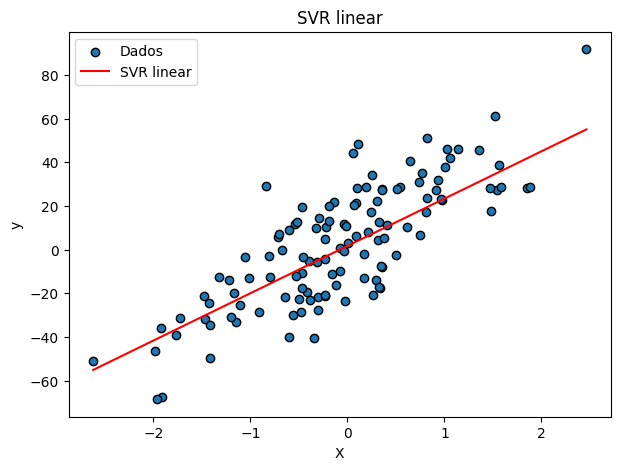

In [ ]:
X_plot = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)
y_plot = regressor.predict(X_plot)

plt.figure(figsize=(7, 5))
plt.scatter(X_reg, y_reg, edgecolor='k', label='Dados')
plt.plot(X_plot, y_plot, color='r', label='SVR linear')
plt.xlabel('X')
plt.ylabel('y')
plt.title('SVR linear')
plt.legend()
plt.show()

## Exemplo de regressão com o SVM (kernel RBF)

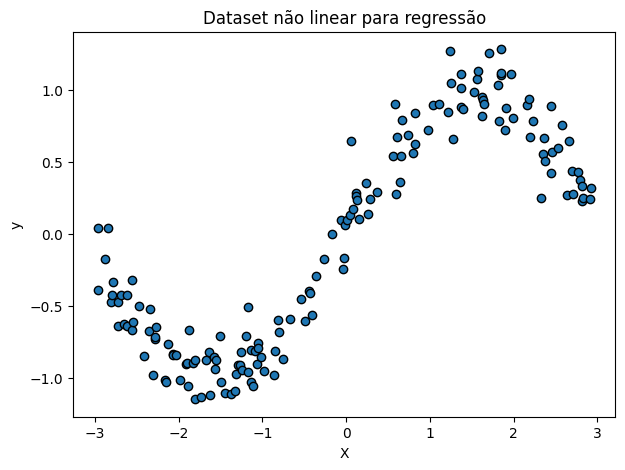

In [ ]:
rng = np.random.RandomState(42)
X_nl = np.sort(6 * rng.rand(160, 1) - 3, axis=0)
y_nl = np.sin(X_nl).ravel() + 0.15 * rng.randn(160)

plt.figure(figsize=(7, 5))
plt.scatter(X_nl, y_nl, edgecolor='k')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Dataset não linear para regressão')
plt.show()

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_nl, y_nl, test_size=0.25, random_state=42
)

regressor = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)

regressor.fit(X_treino, y_treino)

SVR(C=10)

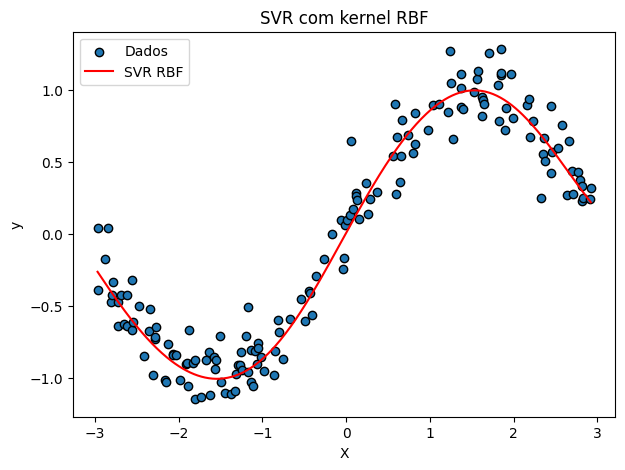

In [ ]:
X_plot_nl = np.linspace(X_nl.min(), X_nl.max(), 400).reshape(-1, 1)
y_plot_nl = regressor.predict(X_plot_nl)

plt.figure(figsize=(7, 5))
plt.scatter(X_nl, y_nl, edgecolor='k', label='Dados')
plt.plot(X_plot_nl, y_plot_nl, color='r', label='SVR RBF')
plt.xlabel('X')
plt.ylabel('y')
plt.title('SVR com kernel RBF')
plt.legend()
plt.show()

## Regressão com diferentes valores para o hyperparâmetro epsilon

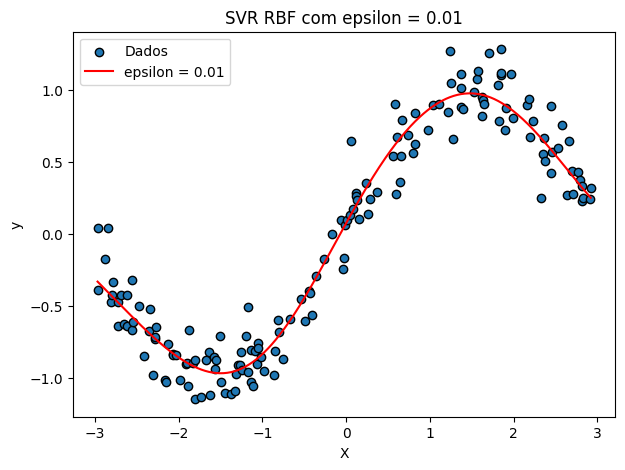

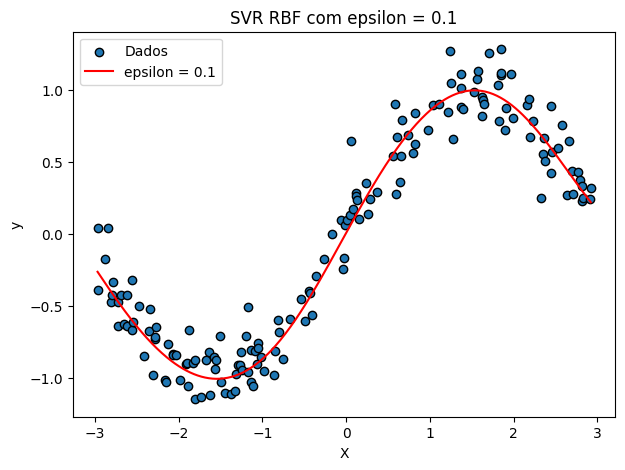

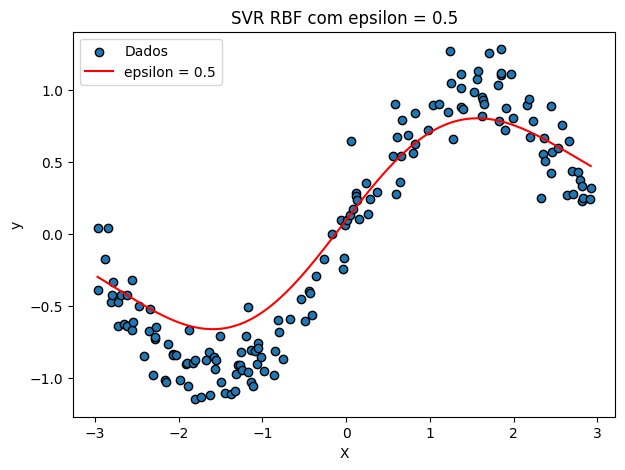

In [ ]:
epsilons = [0.01, 0.1, 0.5]

for eps in epsilons:
    regressor = SVR(kernel='rbf', C=10, gamma='scale', epsilon=eps)
    regressor.fit(X_treino, y_treino)
    y_plot = regressor.predict(X_plot_nl)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_nl, y_nl, edgecolor='k', label='Dados')
    plt.plot(X_plot_nl, y_plot, color='r', label=f'epsilon = {eps}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'SVR RBF com epsilon = {eps}')
    plt.legend()
    plt.show()

## Exemplo de regressão com o SVR

In [ ]:
novo_ponto_reg = np.array([[1.5]])
y_pred = regressor.predict(novo_ponto_reg)

print('Novo ponto:', novo_ponto_reg[0, 0])
print('Valor previsto:', y_pred[0])


Novo ponto: 1.5
Valor previsto: 0.799092714234562


## Cálculo do vetor de pesos $w$ e de bias $b$.

O objetivo do SVM é encontrar um hiperplano que separa as classes com a maior margem possível.

## Intuição Geométrica

classe +1 | margem | hiperplano | margem | classe -1

A margem do SVM é $ \frac{2}{||w||}$.

Quanto menor $ \frac{2}{||w||}$ maior a margem.

O SVM transforma o problema em:

minimizar $\frac{1}{2}||w||^2$

Para cada ponto $y_i(w^Tx_i + b) \geq 1 $

Se $y_i = +1$ então:

$$w^Tx_i + b \geq 1$$

Se $y_i = -1$ então:

$$w^Tx_i + b \leq -1$$


A função Lagrangiana é:

$$
L(w,b,\alpha)
=
\frac{1}{2}\|w\|^2
-
\sum_{i=1}^{2}
\alpha_i
\left[
y_i(w^Tx_i+b)-1
\right]
$$

com:

$$
\alpha_i \geq 0
$$


Os $\alpha_i$ são os multiplicadores de Lagrange.

Supondo os seguintes valores para x:

$$
x_1 =
\begin{bmatrix}
2 \\
2
\end{bmatrix},
\quad y_1 = +1
$$

$$
x_2 =
\begin{bmatrix}
0 \\
0
\end{bmatrix},
\quad y_2 = -1
$$

O objetivo é encontrar o hiperplano:

$$
w^T x + b = 0
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[2, 2],
              [0, 0]])

y = np.array([1, -1])

X, y

(array([[2, 2],
        [0, 0]]),
 array([ 1, -1]))

Derivando a Lagrangiana em relação a \(w\) e igualando a zero:

$$
\frac{\partial L}{\partial w}=0
$$

obtem-se:

$$
w=\sum_{i=1}^{2}\alpha_i y_i x_i
$$

Substituindo os pontos:

$$
w=
\alpha_1(+1)
\begin{bmatrix}
2\\
2
\end{bmatrix}
+
\alpha_2(-1)
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

$$
w=
\begin{bmatrix}
2\alpha_1\\
2\alpha_1
\end{bmatrix}
$$

Derivando em relação a \(b\):

$$
\frac{\partial L}{\partial b}=0
$$

tem-se:

$$
\sum_{i=1}^{2}\alpha_i y_i=0
$$

Logo:

$$
\alpha_1-\alpha_2=0
$$

$$
\alpha_1=\alpha_2=\alpha
$$

Portanto:

$$
w=
\begin{bmatrix}
2\alpha\\
2\alpha
\end{bmatrix}
$$

Como os dois pontos estão exatamente sobre as margens, eles são vetores de suporte. Portanto:

$$
y_i(w^Tx_i+b)=1
$$

### Para o ponto positivo

$$
(+1)(w^Tx_1+b)=1
$$

$$
w^T
\begin{bmatrix}
2\\
2
\end{bmatrix}
+b=1
$$

Como:

$$
w=
\begin{bmatrix}
2\alpha\\
2\alpha
\end{bmatrix}
$$

então:

$$
(2\alpha)(2)+(2\alpha)(2)+b=1
$$

$$
8\alpha+b=1
$$

### Para o ponto negativo

$$
(-1)(w^Tx_2+b)=1
$$

Como $x_2=(0,0)$:

$$
-b=1
$$

$$
b=-1
$$

Substituindo:

$$
8\alpha-1=1
$$

$$
8\alpha=2
$$

$$
\alpha=\frac{1}{4}
$$

In [2]:
alpha = 1/4
w = np.array([2*alpha, 2*alpha])
b = -1

print("alpha =", alpha)
print("w =", w)
print("b =", b)

alpha = 0.25
w = [0.5 0.5]
b = -1


## Resultado Final

Como:

$$
\alpha=\frac{1}{4}
$$

então:

$$
w=
\begin{bmatrix}
2\cdot\frac{1}{4}\\
2\cdot\frac{1}{4}
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2}\\
\frac{1}{2}
\end{bmatrix}
$$

e:

$$
b=-1
$$

Logo, o hiperplano é:

$$
0.5x_1+0.5x_2-1=0
$$

ou, multiplicando tudo por 2:

$$
x_1+x_2-2=0
$$

Portanto, a reta separadora é:

$$
x_2=2-x_1
$$

In [3]:
def decision_function(x):
    return np.dot(w, x) + b

for xi, yi in zip(X, y):
    valor = decision_function(xi)
    pred = np.sign(valor)
    print(f"x = {xi}, y real = {yi}, w^T x + b = {valor:.2f}, predição = {int(pred)}")

x = [2 2], y real = 1, w^T x + b = 1.00, predição = 1
x = [0 0], y real = -1, w^T x + b = -1.00, predição = -1


O hiperplano separador é:

$$
x_1+x_2-2=0
$$

As margens são:

$$
w^Tx+b=+1
$$

e

$$
w^Tx+b=-1
$$

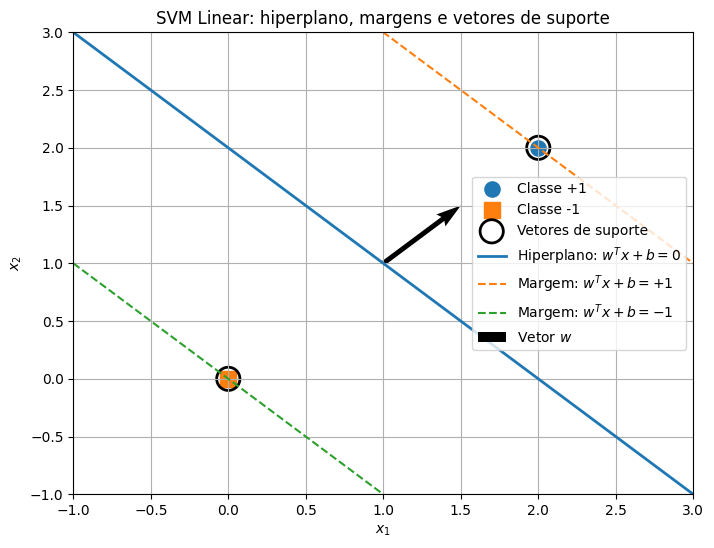

In [4]:
# Malha para desenhar o hiperplano e as margens
x1_vals = np.linspace(-1, 3, 200)

# Hiperplano: 0.5*x1 + 0.5*x2 - 1 = 0
# x2 = -(w1*x1 + b)/w2
x2_hyperplane = -(w[0] * x1_vals + b) / w[1]

# Margens: w^T x + b = +1 e -1
x2_margin_pos = -(w[0] * x1_vals + b - 1) / w[1]
x2_margin_neg = -(w[0] * x1_vals + b + 1) / w[1]

plt.figure(figsize=(8, 6))

# Pontos
plt.scatter(X[0, 0], X[0, 1], s=120, label='Classe +1')
plt.scatter(X[1, 0], X[1, 1], s=120, marker='s', label='Classe -1')

# Destacando vetores de suporte
plt.scatter(X[:, 0], X[:, 1], s=280, facecolors='none', edgecolors='black', linewidths=2, label='Vetores de suporte')

# Hiperplano e margens
plt.plot(x1_vals, x2_hyperplane, linewidth=2, label='Hiperplano: $w^T x + b = 0$')
plt.plot(x1_vals, x2_margin_pos, '--', label='Margem: $w^T x + b = +1$')
plt.plot(x1_vals, x2_margin_neg, '--', label='Margem: $w^T x + b = -1$')

# Vetor w, perpendicular ao hiperplano
origin = np.array([1, 1])
plt.quiver(origin[0], origin[1], w[0], w[1], angles='xy', scale_units='xy', scale=1, width=0.008, label='Vetor $w$')

plt.xlim(-1, 3)
plt.ylim(-1, 3)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM Linear: hiperplano, margens e vetores de suporte')
plt.grid(True)
plt.legend()
plt.show()

# Conclusão

Os valores encontrados foram:

$$
w=
\begin{bmatrix}
0.5\\
0.5
\end{bmatrix}
$$

$$
b=-1
$$

Portanto, a função de decisão do SVM é:

$$
\hat{y}=\operatorname{sign}(0.5x_1+0.5x_2-1)
$$

A reta separadora é:

$$
x_1+x_2=2
$$


A ideia central do Lagrange no SVM é transformar um problema geométrica em um problema de otimização matemática.

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

* Mathematics for Machine Learning (disponível no Moodle).

# Créditos

* Imagens geradas pelo chatgpt.